# Data Science Cohort 7
**Name:** Ezeagu Chibuike Anthony

TASK 3

# Pizza Place Sales Analysis

A year's worth of sales data from a fictitious pizza place, spread across four CSV files (orders, order_details, pizzas, pizza_types). i will merge the datasets into one dataframe before analysis.  

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline



In [2]:
orders = pd.read_csv(r"C:\Users\HomePC\Desktop\Pizza Sales Analysis\pizza Sales\orders.csv")
orders.head()

,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30


In [3]:
orders.shape

(21350, 3)

In [4]:
order_details = pd.read_csv(r"C:\Users\HomePC\Desktop\Pizza Sales Analysis\pizza Sales\order_details.csv")
order_details.head()

,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1


In [5]:
order_details.shape

(48620, 4)

In [6]:
pizzas = pd.read_csv(r"C:\Users\HomePC\Desktop\Pizza Sales Analysis\pizza Sales\pizzas.csv")
pizzas.head()

,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75


In [7]:
pizzas.shape

(96, 4)

In [8]:
#pizza_types has a couple special characters, needs latin-1 encoding or it throws an error

pizza_types = pd.read_csv(r"C:\Users\HomePC\Desktop\Pizza Sales Analysis\pizza Sales\pizza_types.csv", encoding="latin-1")
pizza_types.head()

,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja..."


In [9]:
pizza_types.shape

(32, 4)

In [10]:
#checking for null values in each table before merging

orders.isna().sum()

order_id    0
date        0
time        0
dtype: int64

In [11]:
order_details.isna().sum()

order_details_id    0
order_id            0
pizza_id            0
quantity            0
dtype: int64

In [12]:
pizzas.isna().sum()

pizza_id         0
pizza_type_id    0
size             0
price            0
dtype: int64

In [13]:
pizza_types.isna().sum()

pizza_type_id    0
name             0
category         0
ingredients      0
dtype: int64

## Merging the Four Tables

**order_details** connects to **orders** on **order_id**, to **pizzas** on **pizza_id**, and **pizzas** connects to **pizza_types** on **pizza_type_id**. This is because of the similarity or a common figure in their data making it easier to merge the highlighted duo together

In [14]:
#merge order_details with orders

data = order_details.merge(orders, on="order_id", how="left")
data.head()

,order_details_id,order_id,pizza_id,quantity,date,time
0,1,1,hawaiian_m,1,2015-01-01,11:38:36
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40
2,3,2,five_cheese_l,1,2015-01-01,11:57:40
3,4,2,ital_supr_l,1,2015-01-01,11:57:40
4,5,2,mexicana_m,1,2015-01-01,11:57:40


In [15]:
#merge in pizzas

data = data.merge(pizzas, on="pizza_id", how="left")
data.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,hawaiian,M,13.25
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,classic_dlx,M,16.00
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,five_cheese,L,18.50
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,ital_supr,L,20.75
4,5,2,mexicana_m,1,2015-01-01,11:57:40,mexicana,M,16.00


In [16]:
#merge in pizza_types

data = data.merge(pizza_types, on="pizza_type_id", how="left")
data.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
4,5,2,mexicana_m,1,2015-01-01,11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."


In [17]:
data.shape

(48620, 12)

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_details_id  48620 non-null  int64  
 1   order_id          48620 non-null  int64  
 2   pizza_id          48620 non-null  object 
 3   quantity          48620 non-null  int64  
 4   date              48620 non-null  object 
 5   time              48620 non-null  object 
 6   pizza_type_id     48620 non-null  object 
 7   size              48620 non-null  object 
 8   price             48620 non-null  float64
 9   name              48620 non-null  object 
 10  category          48620 non-null  object 
 11  ingredients       48620 non-null  object 
dtypes: float64(1), int64(3), object(8)
memory usage: 4.5+ MB


In [19]:
#checking for null values after merging

data.isna().sum()

order_details_id    0
order_id            0
pizza_id            0
quantity            0
date                0
time                0
pizza_type_id       0
size                0
price               0
name                0
category            0
ingredients         0
dtype: int64

In [20]:
#check for duplicates

data.duplicated().sum()

np.int64(0)

## Cleaning

Converting the date to a proper datetime, and pulling out the columns needed for the analysis questions.

In [21]:
#converting the date column to datetime data type

data["date"] = pd.to_datetime(data["date"])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_details_id  48620 non-null  int64         
 1   order_id          48620 non-null  int64         
 2   pizza_id          48620 non-null  object        
 3   quantity          48620 non-null  int64         
 4   date              48620 non-null  datetime64[ns]
 5   time              48620 non-null  object        
 6   pizza_type_id     48620 non-null  object        
 7   size              48620 non-null  object        
 8   price             48620 non-null  float64       
 9   name              48620 non-null  object        
 10  category          48620 non-null  object        
 11  ingredients       48620 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(7)
memory usage: 4.5+ MB


In [22]:
#revenue per line item

data["total_price"] = data["quantity"] * data["price"]
data.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients,total_price
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75
4,5,2,mexicana_m,1,2015-01-01,11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00


In [23]:
#to extract the day of the week from the date

data["day_of_week"] = data["date"].dt.day_name()
data.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients,total_price,day_of_week
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25,Thursday
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00,Thursday
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50,Thursday
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75,Thursday
4,5,2,mexicana_m,1,2015-01-01,11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00,Thursday


In [24]:
#to extract month from date

data["month"] = data["date"].dt.month_name()
data.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients,total_price,day_of_week,month
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25,Thursday,January
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00,Thursday,January
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50,Thursday,January
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75,Thursday,January
4,5,2,mexicana_m,1,2015-01-01,11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00,Thursday,January


In [25]:
#extracting hour from the time column

data["hour"] = pd.to_datetime(data["time"], format="%H:%M:%S").dt.hour
data.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients,total_price,day_of_week,month,hour
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25,Thursday,January,11
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00,Thursday,January,11
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50,Thursday,January,11
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75,Thursday,January,11
4,5,2,mexicana_m,1,2015-01-01,11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00,Thursday,January,11


## Analysis

### 1. What is the total revenue?

In [26]:
total_revenue = data["total_price"].sum()
total_revenue

np.float64(817860.0499999999)

**Insight:** Total revenue for the year amounts to **$817,860.05**.

### 2. Total quantity sold

In [27]:
total_quantity = data["quantity"].sum()
total_quantity

np.int64(49574)

**Insight:** **49,574 pizzas** were sold across the year.

### 3. Total orders

In [28]:
total_orders = data["order_id"].nunique()
total_orders

21350

**Insight:** There were **21,350 unique orders**, meaning the average order contains just over 2 pizzas.

### 4. How many pizza types do they sell?

In [29]:
data["pizza_type_id"].nunique()

32

**Insight:** The menu has **32 distinct pizza types**.

### 5. Average price of the pizzas

In [30]:
pizzas["price"].mean()

np.float64(16.440625)

**Insight:** The average price across all pizza/size combinations is **$16.44**.

### 6. Peak hours of sales

In [31]:
orders_by_hour = data.groupby("hour")["order_id"].nunique().sort_values(ascending=False)
orders_by_hour

hour
12    2520
13    2455
18    2399
17    2336
19    2009
16    1920
20    1642
14    1472
15    1468
11    1231
21    1198
22     663
23      28
10       8
9        1
Name: order_id, dtype: int64

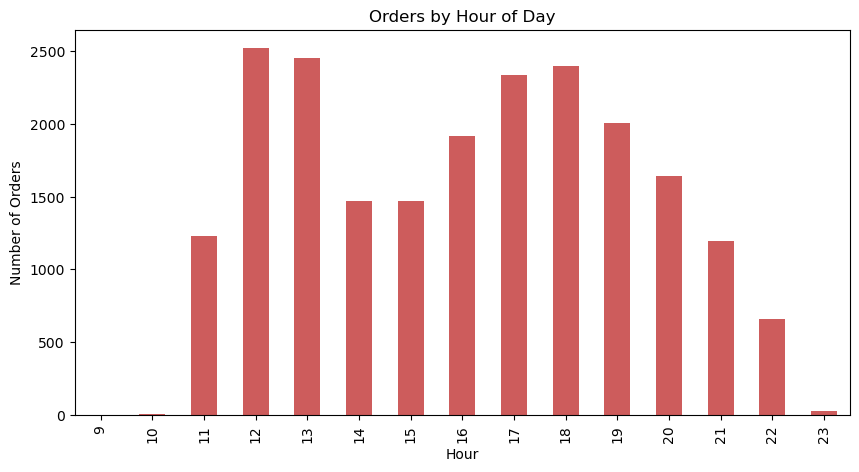

In [32]:
plt.figure(figsize=(10,5))
orders_by_hour.sort_index().plot(kind="bar", color="indianred")
plt.title("Orders by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Orders")
plt.show()

**Insight:** Sales peak around **12-1pm (lunch)** and **5-7pm (dinner)**, with noon being the only busiest hour.

### 7. Total sales by day of the week

In [33]:
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
sales_by_day = data.groupby("day_of_week")["total_price"].sum().reindex(day_order)
sales_by_day

day_of_week
Monday       107329.55
Tuesday      114133.80
Wednesday    114408.40
Thursday     123528.50
Friday       136073.90
Saturday     123182.40
Sunday        99203.50
Name: total_price, dtype: float64

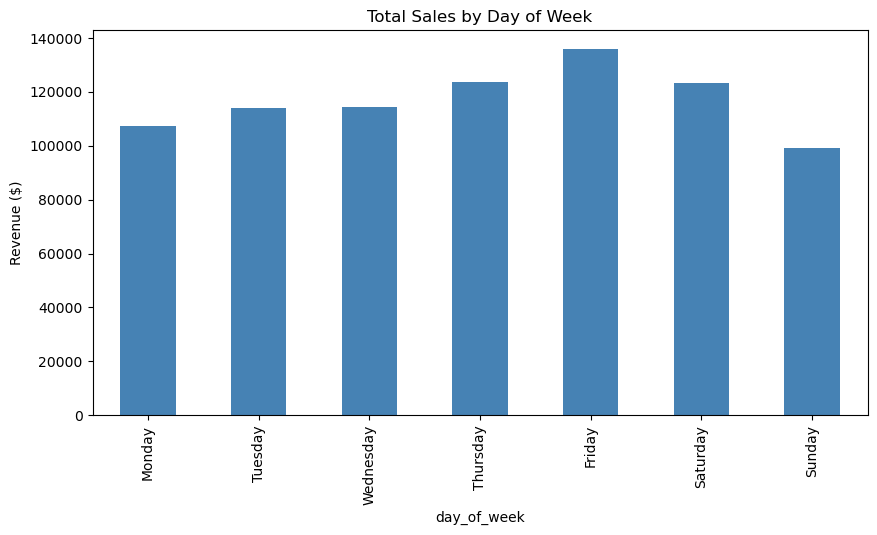

In [34]:
plt.figure(figsize=(10,5))
sales_by_day.plot(kind="bar", color="steelblue")
plt.title("Total Sales by Day of Week")
plt.ylabel("Revenue ($)")
plt.show()

**Insight:** **Friday** brings in the most revenue (~$136,074), while **Sunday** is the slowest day.

### 8. Top 5 bestselling pizzas

In [35]:
top5 = data.groupby("name")["quantity"].sum().sort_values(ascending=False).head(5)
top5

name
The Classic Deluxe Pizza      2453
The Barbecue Chicken Pizza    2432
The Hawaiian Pizza            2422
The Pepperoni Pizza           2418
The Thai Chicken Pizza        2371
Name: quantity, dtype: int64

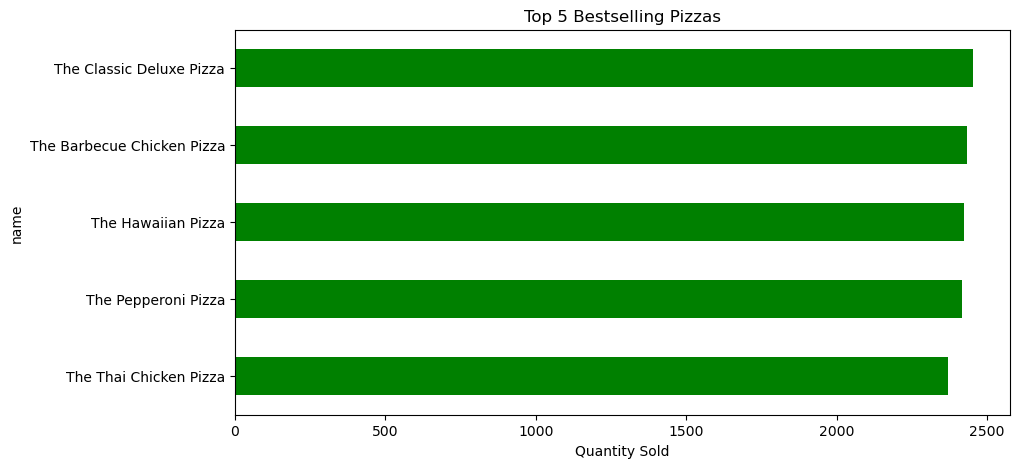

In [45]:
plt.figure(figsize=(10,5))
top5.plot(kind="barh", color="Green")
plt.title("Top 5 Bestselling Pizzas")
plt.xlabel("Quantity Sold")
plt.gca().invert_yaxis()
plt.show()

**Insight:** The **Classic Deluxe**, **Barbecue Chicken**, **Hawaiian**, **Pepperoni**, and **Thai Chicken** pizzas are the top 5 sellers.

### 9. Sales made in each month — any trend?

In [37]:
month_order = ["January","February","March","April","May","June","July","August","September","October","November","December"]
sales_by_month = data.groupby("month")["total_price"].sum().reindex(month_order)
sales_by_month

month
January      69793.30
February     65159.60
March        70397.10
April        68736.80
May          71402.75
June         68230.20
July         72557.90
August       68278.25
September    64180.05
October      64027.60
November     70395.35
December     64701.15
Name: total_price, dtype: float64

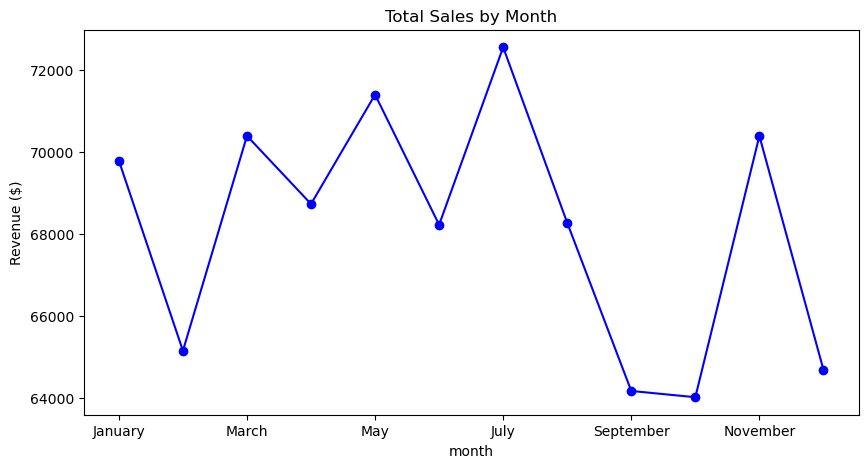

In [44]:
plt.figure(figsize=(10,5))
sales_by_month.plot(kind="line", marker="o", color="blue")
plt.title("Total Sales by Month")
plt.ylabel("Revenue ($)")
plt.show()

**Insight:** Revenue stays fairly steady across the year with no strong seasonal spike, though **July** is slightly the highest and **October** the lowest.

### 10. Are there pizza types that are not doing well on the menu?

In [39]:
bottom5 = data.groupby("name")["quantity"].sum().sort_values().head(5)
bottom5

name
The Brie Carre Pizza         490
The Mediterranean Pizza      934
The Calabrese Pizza          937
The Spinach Supreme Pizza    950
The Soppressata Pizza        961
Name: quantity, dtype: int64

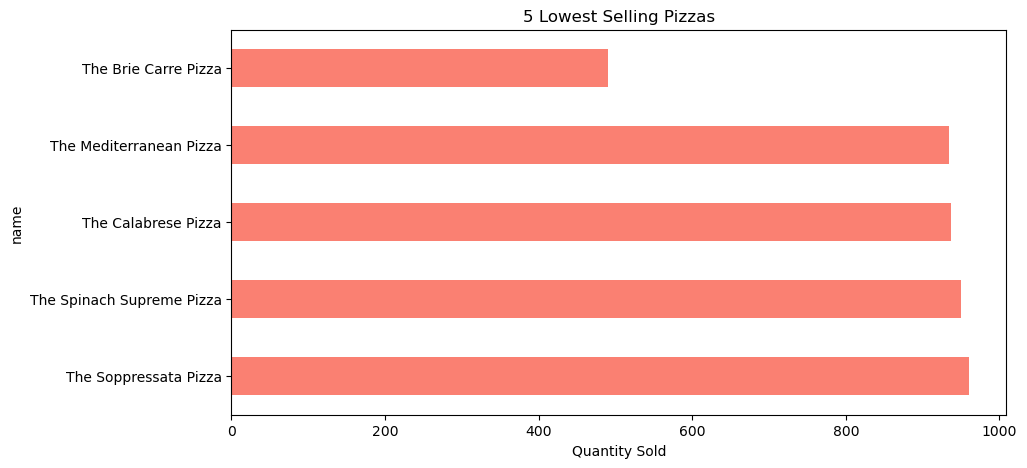

In [40]:
plt.figure(figsize=(10,5))
bottom5.plot(kind="barh", color="salmon")
plt.title("5 Lowest Selling Pizzas")
plt.xlabel("Quantity Sold")
plt.gca().invert_yaxis()
plt.show()

**Insight:** The **Brie Carre** pizza is by far the weakest seller (only 490 units), followed by the Mediterranean, Calabrese, Spinach Supreme, and Soppressata pizzas. These are candidates for removal or a menu redesign.

In [41]:
revenue_by_category = data.groupby("category")["total_price"].sum().sort_values(ascending=False)
revenue_by_category

category
Classic    220053.10
Supreme    208197.00
Chicken    195919.50
Veggie     193690.45
Name: total_price, dtype: float64

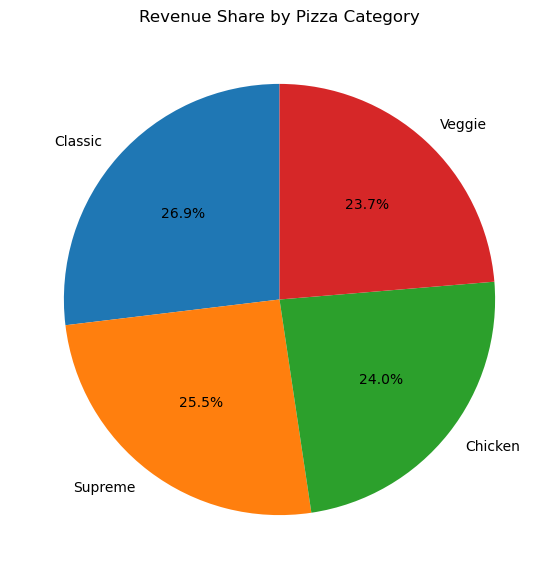

In [42]:
plt.figure(figsize=(7,7))
plt.pie(revenue_by_category, labels=revenue_by_category.index, autopct="%1.1f%%", startangle=90)
plt.title("Revenue Share by Pizza Category")
plt.show()

**Insight:** Classic and Supreme pizzas bring in the most revenue, but all four categories are fairly balanced, each contributing roughly 20-27% of total revenue.

In [43]:
#export the merged and cleaned dataframe to csv

data.to_csv("cleaned_pizza_sales.csv", index=False)

## Summary of my analysis from the datasets

- Total revenue is **$817,860.05** from **21,350 orders** and **49,574 pizzas sold**.
- Sales is highest during **lunch (12-1pm)** and **dinner (5-7pm)**.
- **Friday** is the busiest day; **Sunday** is the low sales day.
- The **Classic Deluxe Pizza** is the No 1 bestseller.
- Sales are consistent across the year with no major seasonal swing.
- The **Brie Carre Pizza** is always underperforming and could be a candidate for removal or a menu redesign.